# DFS Projection Model — Backtest & Feature Analysis

**Backtest period:** 2023–2024 (held-out; model trained on 2009–2022)  
**Models:** Position-specific ElasticNet (StandardScaler + GridSearchCV)  
**Goal:** Validate prediction quality and identify the optimal feature set

---
**Sections**
1. Backtest Overview  
2. Predicted vs Actual Scatter  
3. Calibration (Bias Detection)  
4. Weekly Pearson r — Consistency Over Time  
5. Top-N Ranking Precision  
6. Error Distribution & Worst Misses  
7. Feature Importance — ElasticNet Coefficients  
8. Feature–Target Correlations (Validation Data)  
9. Coefficient vs Correlation Cross-Check  
10. Feature Ablation Study  
11. Feature Optimization Recommendations

In [1]:
import pickle
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#F8F9FA",
    "axes.grid":        True,
    "grid.alpha":       0.35,
    "grid.color":       "white",
    "font.size":        11,
    "axes.spines.top":  False,
    "axes.spines.right": False,
})

ROOT      = Path("..").resolve()
PROCESSED = ROOT / "data" / "processed"
MODELS    = ROOT / "data" / "models"
sys.path.insert(0, str(ROOT / "src"))

POS_COLORS = {"QB": "#2196F3", "RB": "#4CAF50", "WR": "#FF9800", "TE": "#9C27B0"}
POSITIONS  = ["QB", "RB", "WR", "TE"]
TRAIN_MIN, TRAIN_MAX = 2009, 2022
VAL_MIN,   VAL_MAX   = 2023, 2024

print("Environment ready.")

Environment ready.


In [2]:
# --- Load backtest results and trained models ---
bt = pd.read_parquet(PROCESSED / "projections_backtest.parquet")
bt["abs_error"] = bt["error"].abs()

models = {}
for pos in POSITIONS:
    pkg = pickle.load(open(MODELS / f"model_{pos}.pkl", "rb"))
    models[pos] = pkg   # {"model": fitted Pipeline, "features": list[str]}

print(f"Backtest shape: {bt.shape}")
print(f"Seasons: {sorted(bt.season.unique())}")
for pos in POSITIONS:
    n = (bt.position_id == pos).sum()
    print(f"  {pos}: {n:,} player-games")

Backtest shape: (13260, 10)
Seasons: [np.int64(2023), np.int64(2024)]
  QB: 1,351 player-games
  RB: 3,317 player-games
  WR: 5,347 player-games
  TE: 3,245 player-games


## 1. Backtest Overview

In [3]:
rows = []
for pos in POSITIONS:
    sub = bt[bt.position_id == pos]
    act, pred = sub.actual_dk, sub.predicted_dk
    r,   _ = pearsonr(act, pred)
    rho, _ = spearmanr(act, pred)
    mae    = mean_absolute_error(act, pred)
    rmse   = mean_squared_error(act, pred) ** 0.5
    mean_bias = pred.mean() - act.mean()   # positive = over-projection
    wrs = []
    for (s, w), g in sub.groupby(["season", "week"]):
        if len(g) >= 3:
            wr, _ = pearsonr(g.actual_dk, g.predicted_dk)
            wrs.append(wr)
    rows.append({
        "Position": pos, "N": len(sub),
        "MAE": round(mae, 2), "RMSE": round(rmse, 2),
        "Pearson r": round(r, 3), "Spearman ρ": round(rho, 3),
        "Median Wk r": round(float(np.median(wrs)), 3),
        "Mean Bias": round(mean_bias, 3),
    })

summary_df = pd.DataFrame(rows).set_index("Position")
display(
    summary_df.style
    .format({"N": "{:,}", "MAE": "{:.2f}", "RMSE": "{:.2f}",
             "Pearson r": "{:.3f}", "Spearman ρ": "{:.3f}",
             "Median Wk r": "{:.3f}", "Mean Bias": "{:+.3f}"})
    .background_gradient(subset=["Pearson r", "Spearman ρ", "Median Wk r"], cmap="Greens")
    .background_gradient(subset=["MAE", "RMSE"], cmap="Reds_r")
    .set_caption("Model performance on held-out 2023–2024 data")
)

,N,MAE,RMSE,Pearson r,Spearman ρ,Median Wk r,Mean Bias
Position,,,,,,,
QB,"1,351",6.41,8.11,0.567,0.553,0.584,+0.262
RB,"3,317",4.24,6.13,0.668,0.742,0.684,-0.058
WR,"5,347",4.62,6.56,0.608,0.675,0.621,+0.211
TE,"3,245",3.05,4.51,0.618,0.647,0.647,+0.186


## 2. Predicted vs Actual Scatter

Scatter of predicted vs actual DK points across all 2023–2024 player-games.  
- **Dashed line**: perfect prediction (45°)  
- **Solid line**: OLS regression line — slope < 1 means the model compresses the extremes (typical for linear models on heavy-tailed distributions)  

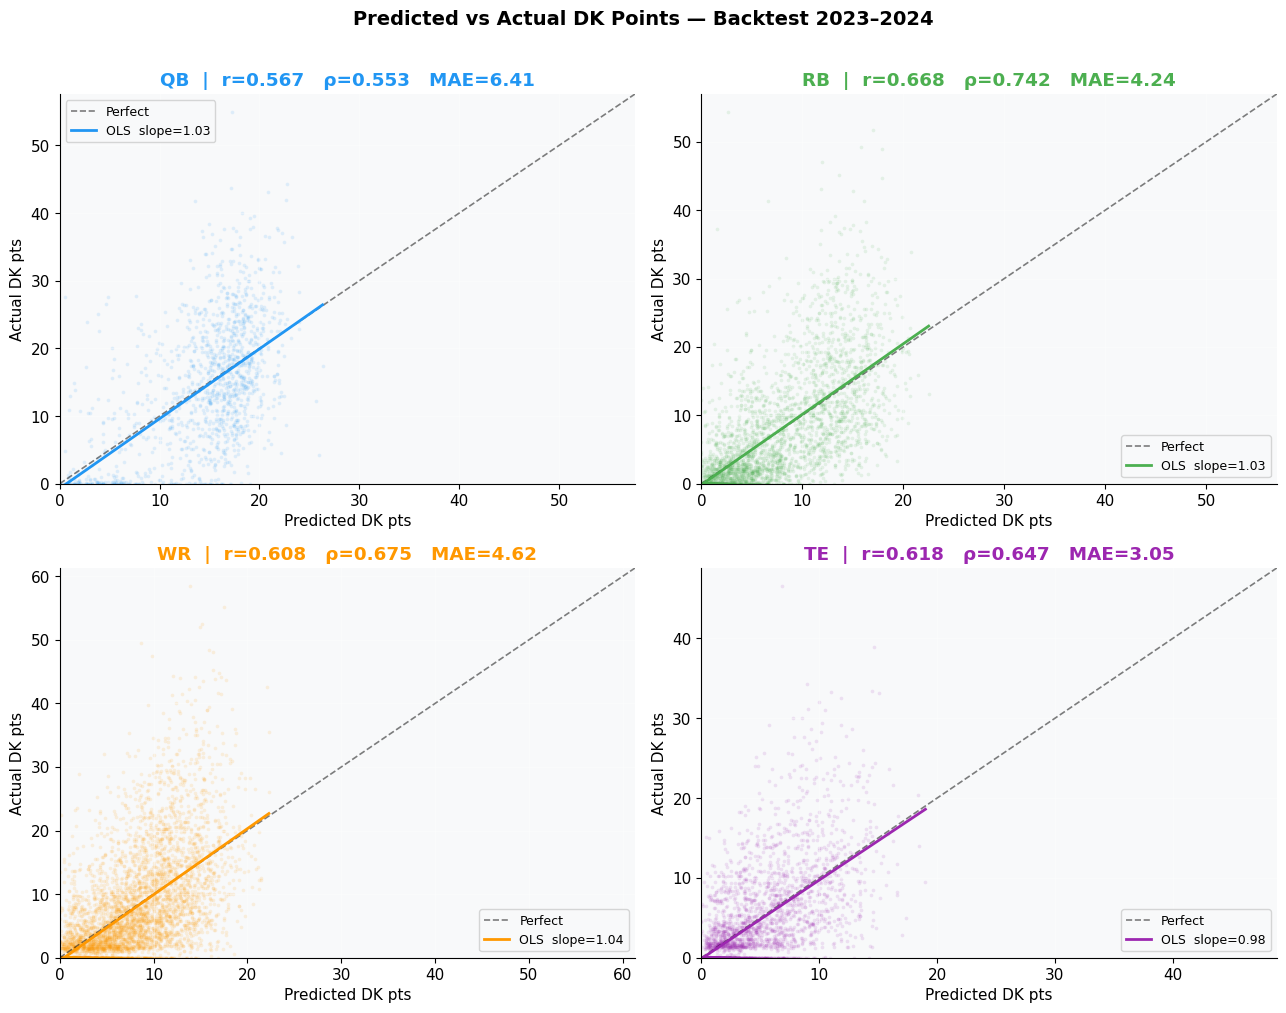

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax, pos in zip(axes, POSITIONS):
    sub  = bt[bt.position_id == pos]
    pred = sub.predicted_dk
    act  = sub.actual_dk
    r,   _ = pearsonr(pred, act)
    rho, _ = spearmanr(pred, act)
    mae    = mean_absolute_error(act, pred)

    ax.scatter(pred, act, alpha=0.12, s=7, color=POS_COLORS[pos], linewidths=0)

    lim = max(pred.max(), act.max()) * 1.05
    ax.plot([0, lim], [0, lim], "k--", lw=1.2, alpha=0.5, label="Perfect")

    slope, intercept = np.polyfit(pred, act, 1)
    xs = np.linspace(0, pred.max(), 100)
    ax.plot(xs, slope * xs + intercept, color=POS_COLORS[pos], lw=2,
            label=f"OLS  slope={slope:.2f}")

    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_xlabel("Predicted DK pts")
    ax.set_ylabel("Actual DK pts")
    ax.set_title(f"{pos}  |  r={r:.3f}   ρ={rho:.3f}   MAE={mae:.2f}",
                 fontweight="bold", color=POS_COLORS[pos])
    ax.legend(fontsize=9)

fig.suptitle("Predicted vs Actual DK Points — Backtest 2023–2024",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("backtest_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Calibration (Bias Detection)

Players are binned into **5 quintiles** by their predicted DK score.  
Bars show the **actual median** per bin; dots show the **predicted median**.  
Error bars are the IQR (25th–75th pct).  
A well-calibrated model has dots and bar tops aligned — systematic divergence signals over/under-projection at extremes.

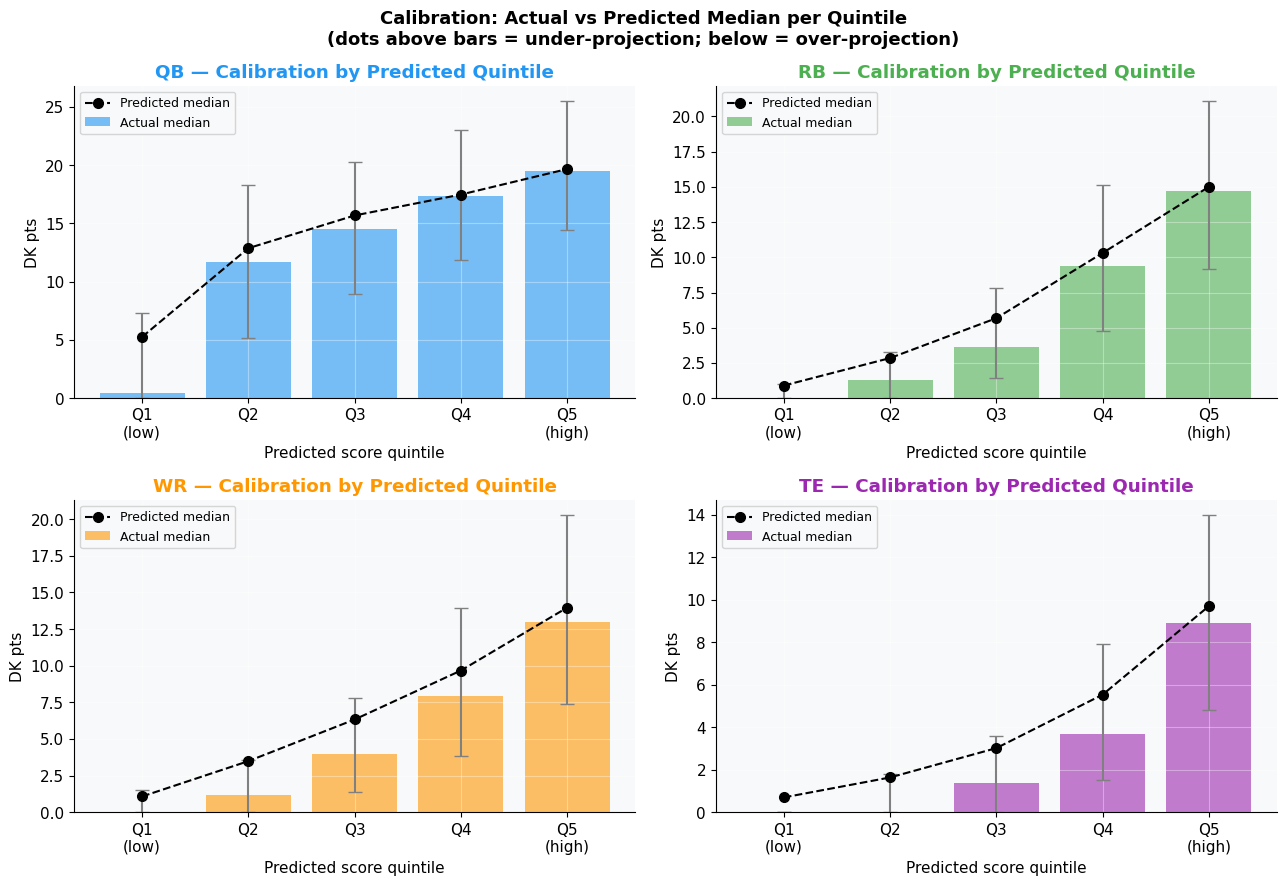

In [5]:
QLABELS = ["Q1\n(low)", "Q2", "Q3", "Q4", "Q5\n(high)"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, pos in zip(axes, POSITIONS):
    sub = bt[bt.position_id == pos].copy()
    sub["pred_q"] = pd.qcut(sub.predicted_dk, q=5, labels=QLABELS)

    grp = sub.groupby("pred_q", observed=True)
    act_med   = grp["actual_dk"].median()
    act_q25   = grp["actual_dk"].quantile(0.25)
    act_q75   = grp["actual_dk"].quantile(0.75)
    pred_med  = grp["predicted_dk"].median()

    xpos = np.arange(5)
    ax.bar(xpos, act_med.values, color=POS_COLORS[pos], alpha=0.6, label="Actual median")
    ax.errorbar(xpos, act_med.values,
                yerr=[act_med.values - act_q25.values,
                      act_q75.values - act_med.values],
                fmt="none", color="gray", capsize=5, lw=1.5)
    ax.plot(xpos, pred_med.values, "ko--", ms=7, lw=1.5, label="Predicted median")

    ax.set_xticks(xpos)
    ax.set_xticklabels(QLABELS)
    ax.set_xlabel("Predicted score quintile")
    ax.set_ylabel("DK pts")
    ax.set_title(f"{pos} — Calibration by Predicted Quintile",
                 fontweight="bold", color=POS_COLORS[pos])
    ax.legend(fontsize=9)

fig.suptitle("Calibration: Actual vs Predicted Median per Quintile\n"
             "(dots above bars = under-projection; below = over-projection)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("backtest_calibration.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Weekly Pearson r — Consistency Over Time

One Pearson r per week (2023 W1 → 2024 W18).  
Red bars = weeks where the model failed to rank players positively.  
Dashed line = median weekly r. The ideal model is **consistently above 0.5** with few red bars.

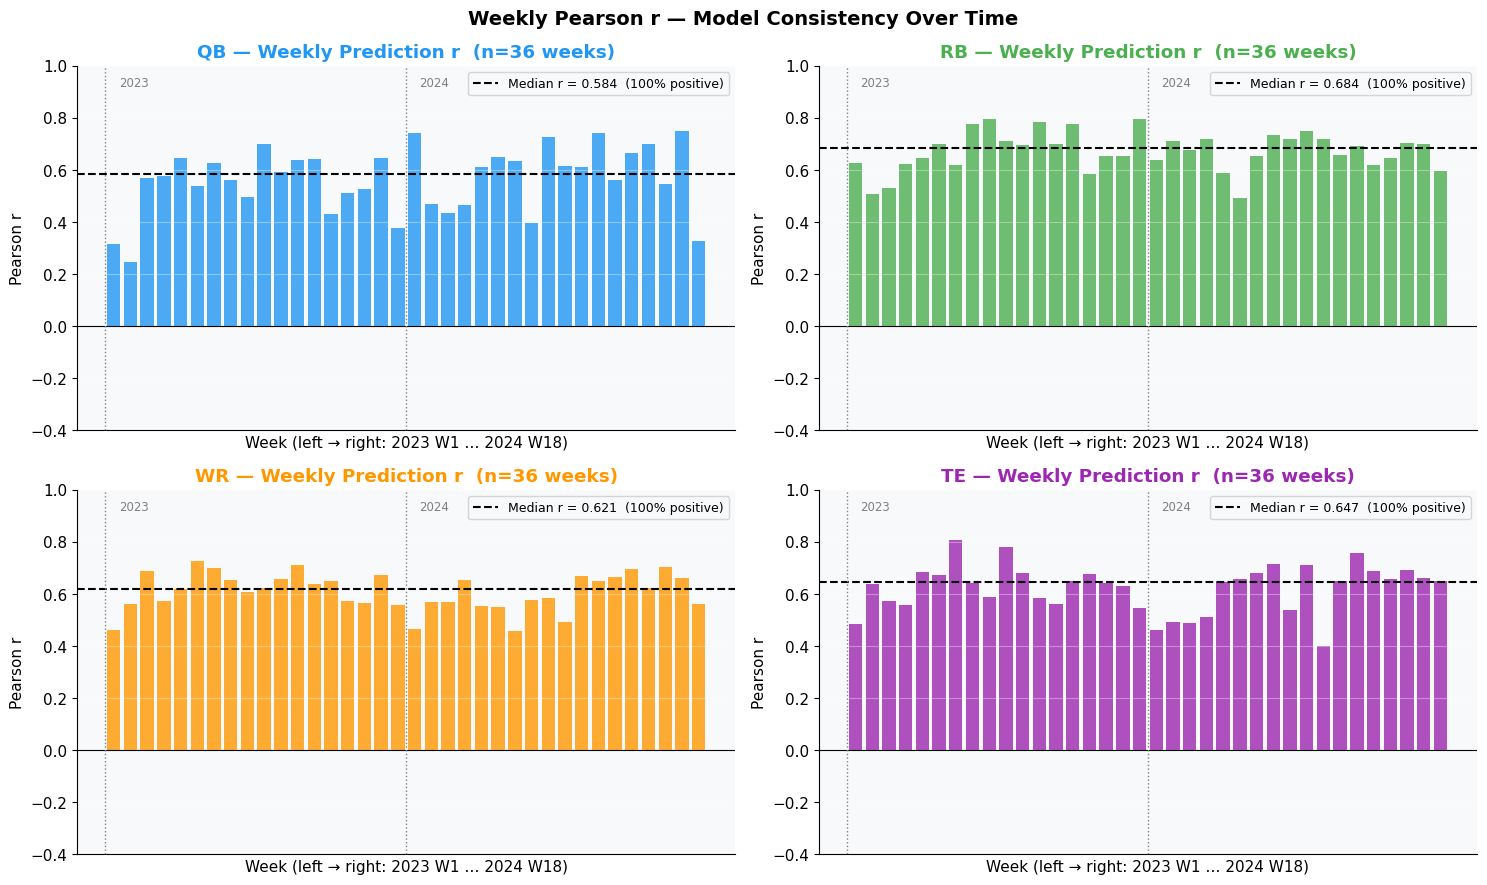

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.flatten()

for ax, pos in zip(axes, POSITIONS):
    sub = bt[bt.position_id == pos]

    week_data = []
    for (ssn, wk), grp in sub.groupby(["season", "week"]):
        if len(grp) >= 3:
            wr, _ = pearsonr(grp.actual_dk, grp.predicted_dk)
            week_data.append({"season": ssn, "week": wk, "r": wr})
    wdf = pd.DataFrame(week_data).reset_index(drop=True)

    bar_colors = [POS_COLORS[pos] if r >= 0 else "#EF5350" for r in wdf.r]
    ax.bar(range(len(wdf)), wdf.r, color=bar_colors, alpha=0.8, edgecolor="none")

    med_r = float(wdf.r.median())
    pct_pos = 100 * (wdf.r >= 0).mean()
    ax.axhline(med_r, color="black", lw=1.5, ls="--",
               label=f"Median r = {med_r:.3f}  ({pct_pos:.0f}% positive)")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_ylim(-0.4, 1.0)

    # Season boundary markers
    for ssn in sorted(wdf.season.unique()):
        first_i = wdf[wdf.season == ssn].index[0]
        ax.axvline(first_i - 0.5, color="gray", lw=1, ls=":")
        ax.text(first_i + 0.3, 0.92, str(ssn), fontsize=8.5, color="gray")

    ax.set_xticks([])
    ax.set_xlabel("Week (left → right: 2023 W1 … 2024 W18)")
    ax.set_ylabel("Pearson r")
    ax.set_title(f"{pos} — Weekly Prediction r  (n={len(wdf)} weeks)",
                 fontweight="bold", color=POS_COLORS[pos])
    ax.legend(fontsize=9)

fig.suptitle("Weekly Pearson r — Model Consistency Over Time",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("backtest_weekly_r.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Top-N Ranking Precision

**Precision@N** = fraction of actual top-N scorers that the model predicted in its top-N.  
This is the DFS-critical metric: we care about ranking the *right players* for lineup construction.

Computed per week, then averaged over the 36 backtest weeks.

In [7]:
def precision_at_n(grp: pd.DataFrame, n: int) -> float:
    """Fraction of actual top-N that appear in predicted top-N."""
    top_pred = set(grp.nlargest(n, "predicted_dk").index)
    top_act  = set(grp.nlargest(n, "actual_dk").index)
    return len(top_pred & top_act) / n

# Also compute a simple baseline: predict everyone at their position average
# (baseline = random, so precision@N ≈ N / pool_size)
prec_rows = []
for pos in POSITIONS:
    sub = bt[bt.position_id == pos]
    pool_size = sub.groupby(["season", "week"]).size().median()
    p5, p10, p15, n_weeks = [], [], [], 0
    for (s, w), grp in sub.groupby(["season", "week"]):
        if len(grp) < 10:
            continue
        n_weeks += 1
        p5.append(precision_at_n(grp, 5))
        p10.append(precision_at_n(grp, 10))
        if len(grp) >= 15:
            p15.append(precision_at_n(grp, 15))

    random_p5  = 5  / pool_size
    random_p10 = 10 / pool_size
    prec_rows.append({
        "Position": pos,
        "Avg pool size": int(pool_size),
        "P@5 (model)": f"{np.mean(p5):.1%}",
        "P@5 (random)": f"{random_p5:.1%}",
        "P@10 (model)": f"{np.mean(p10):.1%}",
        "P@10 (random)": f"{random_p10:.1%}",
        "P@15 (model)": f"{np.mean(p15):.1%}" if p15 else "—",
        "Weeks": n_weeks,
    })

prec_df = pd.DataFrame(prec_rows).set_index("Position")
display(prec_df.style.set_caption(
    "Precision@N: fraction of actual top scorers the model correctly ranked top-N per week"
))

,Avg pool size,P@5 (model),P@5 (random),P@10 (model),P@10 (random),P@15 (model),Weeks
Position,,,,,,,
QB,36,30.6%,13.7%,47.2%,27.4%,60.4%,36
RB,92,23.9%,5.4%,35.3%,10.8%,48.5%,36
WR,150,17.8%,3.3%,28.3%,6.7%,35.0%,36
TE,91,32.8%,5.5%,44.2%,10.9%,52.4%,36


## 6. Error Distribution & Worst Misses

Distribution of `error = predicted − actual`.  
- Right tail = under-projections (player blew up unexpectedly)  
- Left tail = over-projections (player busted despite strong prior history)  
- Mean near 0 confirms the model is unbiased on average

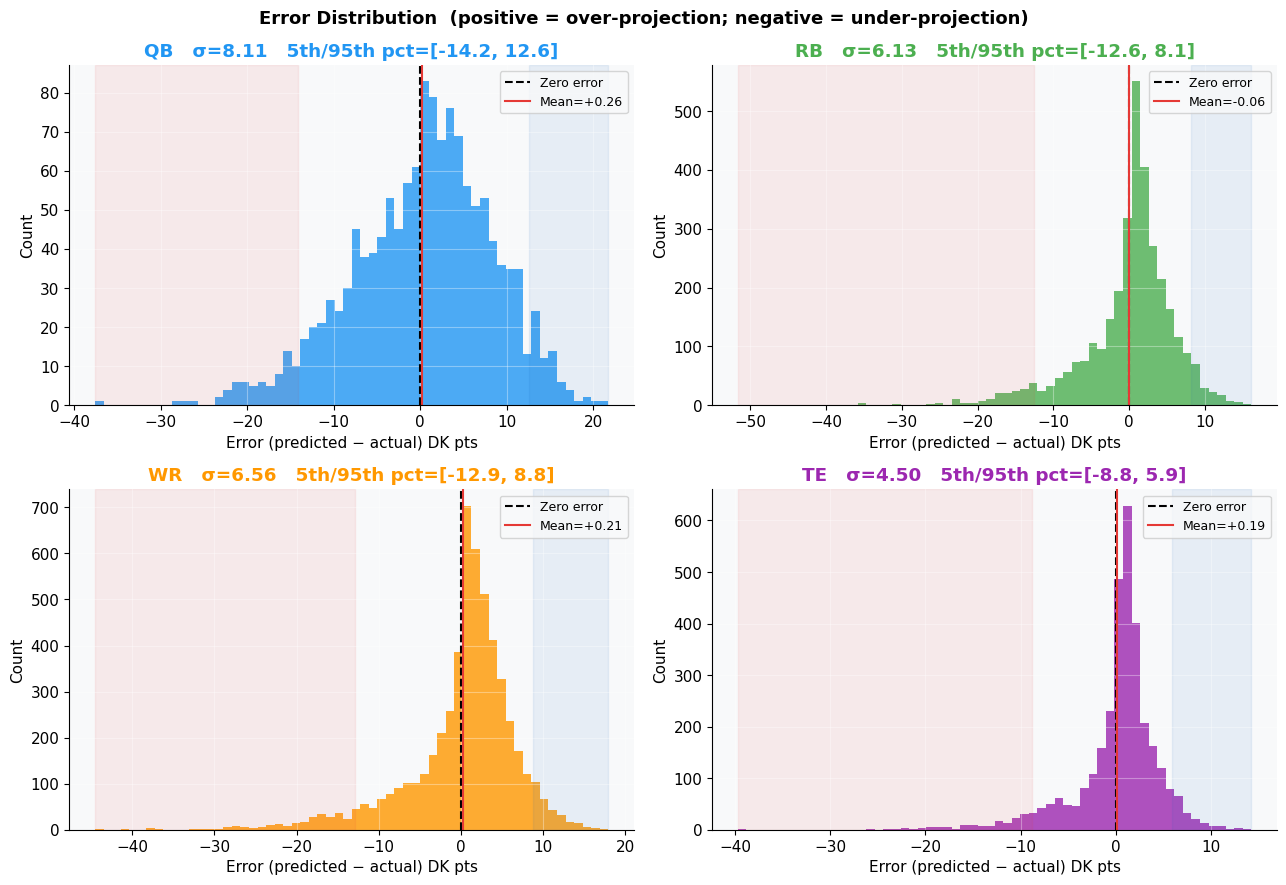

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, pos in zip(axes, POSITIONS):
    sub  = bt[bt.position_id == pos]
    errs = sub.error

    ax.hist(errs, bins=60, color=POS_COLORS[pos], alpha=0.8, edgecolor="none")
    ax.axvline(0, color="black", lw=1.5, ls="--", label="Zero error")
    ax.axvline(errs.mean(), color="#E53935", lw=1.5, ls="-",
               label=f"Mean={errs.mean():+.2f}")

    p5  = errs.quantile(0.05)
    p95 = errs.quantile(0.95)
    ax.axvspan(errs.min(), p5, alpha=0.08, color="#E53935")
    ax.axvspan(p95, errs.max(), alpha=0.08, color="#1565C0")

    ax.set_xlabel("Error (predicted − actual) DK pts")
    ax.set_ylabel("Count")
    ax.set_title(f"{pos}   σ={errs.std():.2f}   5th/95th pct=[{p5:.1f}, {p95:.1f}]",
                 fontweight="bold", color=POS_COLORS[pos])
    ax.legend(fontsize=9)

fig.suptitle("Error Distribution  (positive = over-projection; negative = under-projection)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("backtest_errors.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# Worst misses — largest absolute errors
worst = (
    bt.nlargest(25, "abs_error")
    [["name", "position_id", "season", "week",
      "predicted_dk", "actual_dk", "error"]]
    .reset_index(drop=True)
)
display(
    worst.style
    .format({"predicted_dk": "{:.1f}", "actual_dk": "{:.1f}", "error": "{:+.1f}"})
    .background_gradient(subset=["error"], cmap="RdBu", vmin=-40, vmax=40)
    .set_caption("Top 25 worst misses (by absolute error)")
)

,name,position_id,season,week,predicted_dk,actual_dk,error
0,De'Von Achane,RB,2023,3,2.7,54.3,-51.6
1,Ja'Marr Chase,WR,2024,10,13.9,58.4,-44.5
2,Jauan Jennings,WR,2024,3,8.7,49.5,-40.8
3,Taysom Hill,TE,2024,11,6.8,46.5,-39.7
4,Ja'Marr Chase,WR,2023,5,17.5,55.2,-37.7
5,Josh Allen,QB,2024,14,17.3,54.9,-37.6
6,Tyreek Hill,WR,2023,1,9.9,47.5,-37.6
7,Amari Cooper,WR,2023,16,15.1,52.5,-37.4
8,D.J. Moore,WR,2023,5,14.9,52.0,-37.1
9,Sean Tucker,RB,2024,6,1.6,37.2,-35.6


## 7. Feature Importance — ElasticNet Coefficients

Coefficients are in **StandardScaler space** (features are unit-normalized before fitting), so they are directly comparable across features within a position.  

Key interpretation rules:
- **|coef| near 0** → feature contributes almost nothing; candidate for removal  
- **Negative efficiency coef** (e.g. `yards_per_attempt_lag1` for QB) → likely suppressed by a correlated volume feature (`passing_yds_lag1` encodes YPA × ATT); multicollinearity artifact  
- **Lag2 coefs nearly as large as lag1** → two games of history genuinely adds information

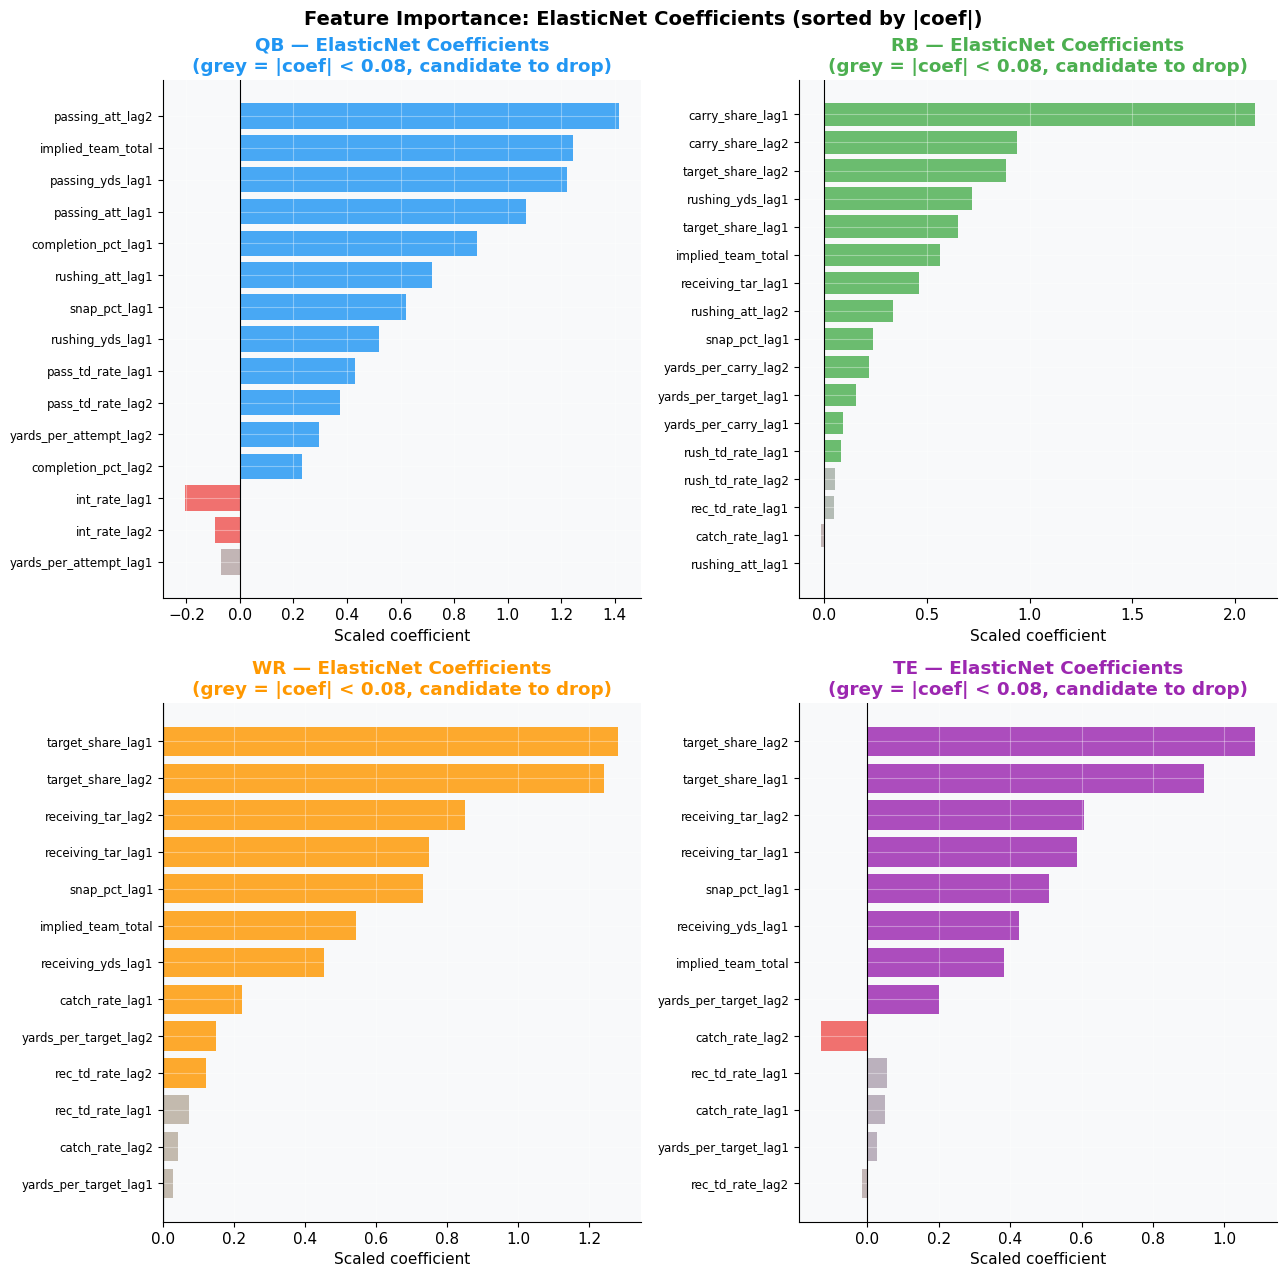

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 13))
axes = axes.flatten()

for ax, pos in zip(axes, POSITIONS):
    m     = models[pos]
    feats = m["features"]
    coefs = m["model"].named_steps["elasticnet"].coef_

    # Sort by absolute value ascending (so most important is at top)
    order        = np.argsort(np.abs(coefs))
    sorted_feats = [feats[i] for i in order]
    sorted_coefs = coefs[order]

    bar_colors = [POS_COLORS[pos] if c >= 0 else "#EF5350" for c in sorted_coefs]
    ypos = range(len(sorted_coefs))

    ax.barh(ypos, sorted_coefs, color=bar_colors, alpha=0.82, edgecolor="none")
    ax.axvline(0, color="black", lw=0.8)

    # Highlight near-zero features
    for i, (f, c) in enumerate(zip(sorted_feats, sorted_coefs)):
        if abs(c) < 0.08:
            ax.barh(i, c, color="#BDBDBD", alpha=0.9, edgecolor="none")

    ax.set_yticks(ypos)
    ax.set_yticklabels(sorted_feats, fontsize=8.5)
    ax.set_xlabel("Scaled coefficient")
    ax.set_title(f"{pos} — ElasticNet Coefficients\n(grey = |coef| < 0.08, candidate to drop)",
                 fontweight="bold", color=POS_COLORS[pos])

fig.suptitle("Feature Importance: ElasticNet Coefficients (sorted by |coef|)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("backtest_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Feature–Target Correlations (Validation Data)

Pearson r between each feature and `dk_points` in the **held-out 2023–2024** data.  
This is the raw signal strength of each feature in the period the model is evaluated on.

In [11]:
from projections import (
    _load_schedule_implied, _load_position_data, _prepare_Xy, FEATURES
)

sched_ctx = _load_schedule_implied()

feat_analysis = {}   # pos -> DataFrame with feature, coef, feat_r
val_dfs = {}

for pos in POSITIONS:
    df_all = _load_position_data(pos, sched_ctx)
    X_all, y_all, meta_all = _prepare_Xy(pos, df_all)

    val_mask  = meta_all["season"].between(VAL_MIN, VAL_MAX)
    X_val     = X_all[val_mask].reset_index(drop=True)
    y_val     = y_all[val_mask].reset_index(drop=True)
    val_dfs[pos] = (X_val, y_val)

    feats = FEATURES[pos]
    coefs = models[pos]["model"].named_steps["elasticnet"].coef_

    rows = []
    for f, coef in zip(feats, coefs):
        if f in X_val.columns:
            feat_r, _ = pearsonr(X_val[f].fillna(0), y_val)
        else:
            feat_r = 0.0
        rows.append({"feature": f, "coef": coef, "abs_coef": abs(coef), "feat_r": feat_r})

    feat_analysis[pos] = pd.DataFrame(rows)

print("Feature correlations computed for validation period.\n")

for pos in POSITIONS:
    fa = feat_analysis[pos].sort_values("abs_coef", ascending=False)
    print(f"\n{'─'*62}")
    print(f"  {pos}")
    print(f"  {'Feature':<35} {'Coef':>8}  {'r vs dk':>8}")
    print(f"  {'─'*55}")
    for _, row in fa.iterrows():
        flag = "  ← near-zero" if row.abs_coef < 0.08 else ""
        print(f"  {row.feature:<35} {row.coef:>+8.4f}  {row.feat_r:>8.3f}{flag}")

Feature correlations computed for validation period.


──────────────────────────────────────────────────────────────
  QB
  Feature                                 Coef   r vs dk
  ───────────────────────────────────────────────────────
  passing_att_lag2                     +1.4170     0.412
  implied_team_total                   +1.2423     0.217
  passing_yds_lag1                     +1.2218     0.478
  passing_att_lag1                     +1.0691     0.464
  completion_pct_lag1                  +0.8845     0.364
  rushing_att_lag1                     +0.7177     0.289
  snap_pct_lag1                        +0.6211     0.460
  rushing_yds_lag1                     +0.5195     0.254
  pass_td_rate_lag1                    +0.4306     0.204
  pass_td_rate_lag2                    +0.3746     0.193
  yards_per_attempt_lag2               +0.2973     0.325
  completion_pct_lag2                  +0.2321     0.328
  int_rate_lag1                        -0.2057     0.005
  int_rate_lag2      

## 9. Coefficient vs Correlation Cross-Check

**X-axis**: Raw feature–target Pearson r (how correlated the feature is with dk_points alone)  
**Y-axis**: Scaled ElasticNet coefficient (how much the model *actually uses* the feature)

Interpretation:
- **High r, high coef** → genuinely informative feature, model uses it correctly  
- **High r, low coef** → multicollinearity; another feature carries the same signal  
- **Low r, high coef** → the feature adds value *in combination* with others (interaction effect)  
- **Both low** → strong candidate for removal

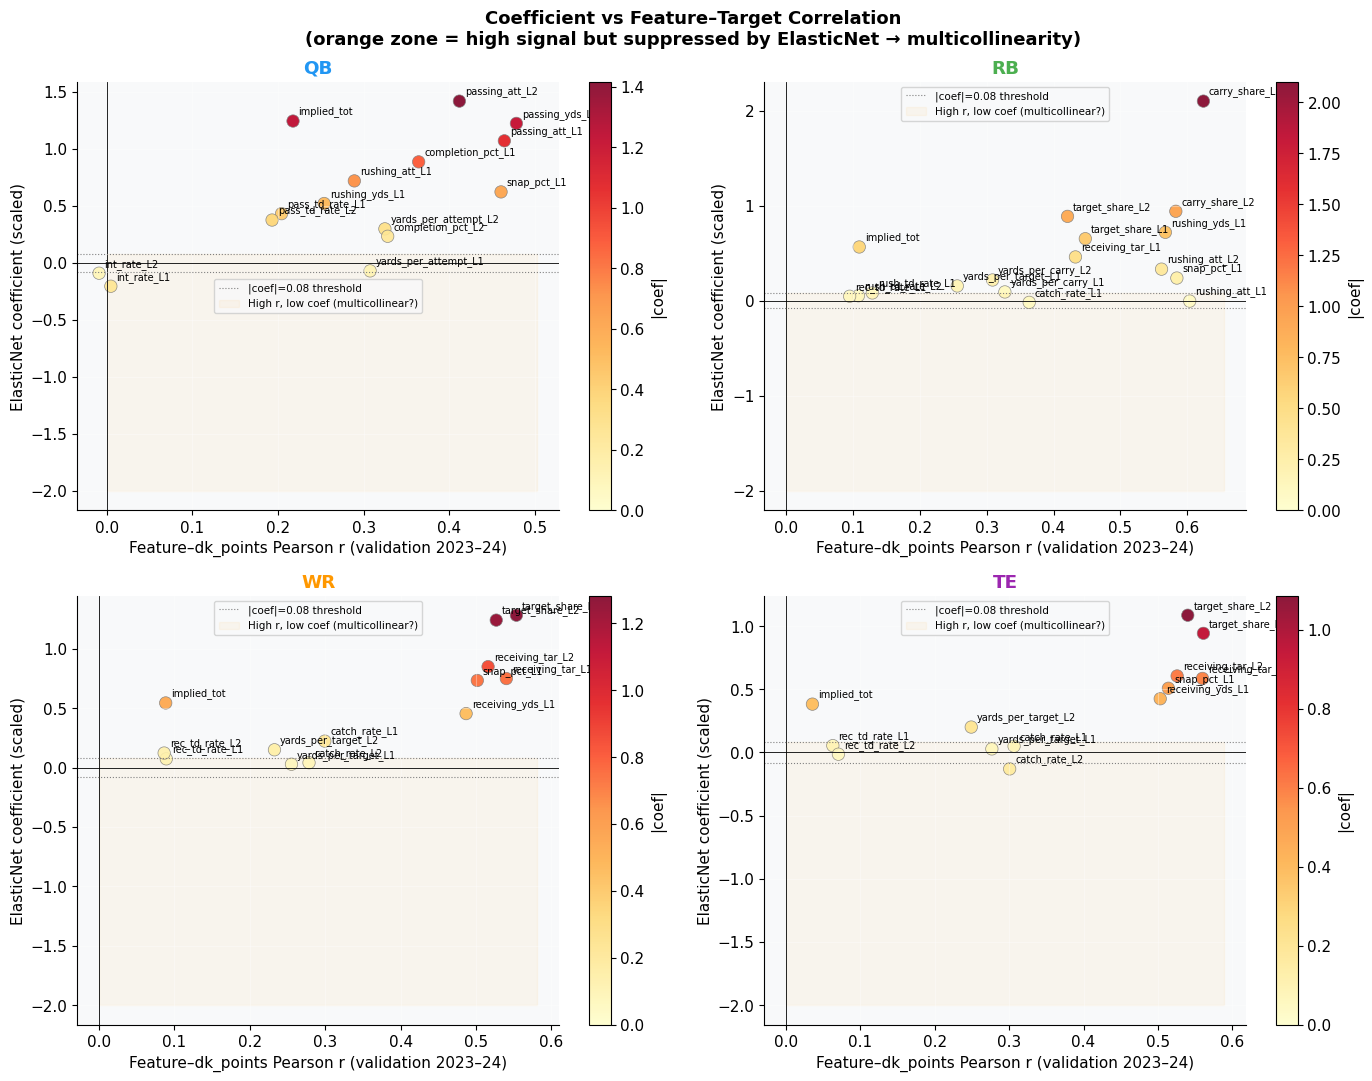

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for ax, pos in zip(axes, POSITIONS):
    fa = feat_analysis[pos]

    sc = ax.scatter(
        fa.feat_r, fa.coef,
        c=fa.abs_coef, cmap="YlOrRd",
        s=80, alpha=0.9, edgecolors="gray", linewidths=0.5,
        vmin=0, vmax=fa.abs_coef.max()
    )
    plt.colorbar(sc, ax=ax, label="|coef|")

    for _, row in fa.iterrows():
        short = (row.feature
                 .replace("_lag1", "_L1")
                 .replace("_lag2", "_L2")
                 .replace("implied_team_total", "implied_tot"))
        ax.annotate(short, (row.feat_r, row.coef),
                    fontsize=7, ha="left", va="bottom",
                    xytext=(4, 3), textcoords="offset points")

    ax.axhline(0, color="black", lw=0.6)
    ax.axvline(0, color="black", lw=0.6)
    ax.axhline(0.08, color="gray", lw=0.8, ls=":", label="|coef|=0.08 threshold")
    ax.axhline(-0.08, color="gray", lw=0.8, ls=":")

    # Quadrant shading
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    ax.fill_between([0, max(xlim[1], 0.5)], [-2, -2], [0.08, 0.08],
                    alpha=0.05, color="orange", label="High r, low coef (multicollinear?)")

    ax.set_xlabel("Feature–dk_points Pearson r (validation 2023–24)")
    ax.set_ylabel("ElasticNet coefficient (scaled)")
    ax.set_title(f"{pos}", fontweight="bold", color=POS_COLORS[pos])
    ax.legend(fontsize=7.5)

fig.suptitle("Coefficient vs Feature–Target Correlation\n"
             "(orange zone = high signal but suppressed by ElasticNet → multicollinearity)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("backtest_coef_vs_corr.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Feature Ablation Study

We compare **5-fold CV MAE** on the training set (2009–2022) under two feature sets:
- **Full**: all features as currently defined  
- **Reduced**: near-zero features removed (|scaled coef| < 0.08)

A ΔΔ MAE near 0 means the removed features contributed nothing. Positive Δ = removing them *hurts* the model.

In [13]:
ZERO_THRESH = 0.08  # scaled coefficient magnitude below which we call a feature "near-zero"

ablation_rows = []

for pos in POSITIONS:
    df_all = _load_position_data(pos, sched_ctx)
    X_all, y_all, meta_all = _prepare_Xy(pos, df_all)

    train_mask = meta_all["season"].between(TRAIN_MIN, TRAIN_MAX)
    X_tr, y_tr = X_all[train_mask], y_all[train_mask]

    feats = FEATURES[pos]
    coefs = models[pos]["model"].named_steps["elasticnet"].coef_

    zero_feats = [f for f, c in zip(feats, coefs) if abs(c) < ZERO_THRESH]
    keep_feats = [f for f in feats if f not in zero_feats]

    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("en",     ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=5000, random_state=42)),
    ])

    full_mae = -cross_val_score(
        pipe, X_tr[feats], y_tr,
        cv=cv, scoring="neg_mean_absolute_error", n_jobs=-1
    ).mean()

    if zero_feats:
        red_mae = -cross_val_score(
            pipe, X_tr[keep_feats], y_tr,
            cv=cv, scoring="neg_mean_absolute_error", n_jobs=-1
        ).mean()
    else:
        red_mae = full_mae

    delta = red_mae - full_mae
    ablation_rows.append({
        "Position":             pos,
        "Full features":        len(feats),
        "Reduced features":     len(keep_feats),
        "Dropped features":     ", ".join(zero_feats) if zero_feats else "—",
        "CV MAE (full)": round(full_mae, 3),
        "CV MAE (reduced)": round(red_mae, 3),
        "Δ MAE (reduced−full)": round(delta, 3),
    })
    print(f"{pos}: dropped {len(zero_feats)} features  Δ MAE = {delta:+.3f}")

abl_df = pd.DataFrame(ablation_rows).set_index("Position")
display(
    abl_df.style
    .format({"CV MAE (full)": "{:.3f}", "CV MAE (reduced)": "{:.3f}",
             "Δ MAE (reduced−full)": "{:+.3f}"})
    .background_gradient(subset=["Δ MAE (reduced−full)"], cmap="RdYlGn_r", vmin=-0.05, vmax=0.05)
    .set_caption("Ablation: CV MAE with vs without near-zero features (|coef| < 0.08)")
)

QB: dropped 1 features  Δ MAE = -0.000


RB: dropped 4 features  Δ MAE = -0.001


WR: dropped 3 features  Δ MAE = +0.001


TE: dropped 4 features  Δ MAE = +0.002


,Full features,Reduced features,Dropped features,CV MAE (full),CV MAE (reduced),Δ MAE (reduced−full)
Position,,,,,,
QB,15,14,yards_per_attempt_lag1,6.407,6.407,-0.000
RB,17,13,"rush_td_rate_lag2, rushing_att_lag1, catch_rate_lag1, rec_td_rate_lag1",4.200,4.200,-0.001
WR,13,10,"catch_rate_lag2, yards_per_target_lag1, rec_td_rate_lag1",4.837,4.838,+0.001
TE,13,9,"catch_rate_lag1, yards_per_target_lag1, rec_td_rate_lag1, rec_td_rate_lag2",3.256,3.258,+0.002


## 11. Feature Optimization Recommendations

Summary table combining coefficient magnitude, raw feature–target correlation, and ablation outcome.  

**Action codes:**
- `KEEP` — large coefficient, clear signal  
- `INVESTIGATE` — high feature–target r but low model coefficient → multicollinearity with another feature  
- `DROP?` — near-zero coefficient AND ablation confirms no MAE impact  
- `MONITOR` — near-zero coefficient but ablation shows removing it has cost  

In [14]:
# Build ablation delta lookup
ablation_delta = {row["Position"]: row["Δ MAE (reduced−full)"] for row in ablation_rows}

recommendation_rows = []
for pos in POSITIONS:
    fa     = feat_analysis[pos].sort_values("abs_coef", ascending=False)
    d_mae  = ablation_delta.get(pos, 0)

    for _, row in fa.iterrows():
        if row.abs_coef >= 0.15:
            action = "KEEP"
        elif row.abs_coef >= 0.08:
            action = "KEEP (borderline)"
        else:
            # Near-zero coef
            if row.feat_r > 0.3:
                action = "INVESTIGATE (multicollinear?)"
            elif d_mae > 0.01:
                action = "MONITOR (drops hurt)"
            else:
                action = "DROP?"

        recommendation_rows.append({
            "Pos": pos,
            "Feature": row.feature,
            "Coef (scaled)": round(row.coef, 4),
            "|Coef|": round(row.abs_coef, 4),
            "Feature r": round(row.feat_r, 3),
            "Action": action,
        })

rec_df = pd.DataFrame(recommendation_rows)

def color_action(val):
    if val == "KEEP":                         return "background-color: #C8E6C9"
    if val == "KEEP (borderline)":            return "background-color: #DCEDC8"
    if val == "DROP?":                        return "background-color: #FFCDD2"
    if val.startswith("INVESTIGATE"):         return "background-color: #FFF9C4"
    if val.startswith("MONITOR"):             return "background-color: #FFE0B2"
    return ""

display(
    rec_df.style
    .format({"Coef (scaled)": "{:+.4f}", "|Coef|": "{:.4f}", "Feature r": "{:.3f}"})
    .map(color_action, subset=["Action"])
    .set_caption("Feature Optimization Recommendations (sorted by |coef| desc per position)")
    .hide(axis="index")
)

Pos,Feature,Coef (scaled),|Coef|,Feature r,Action
QB,passing_att_lag2,+1.4170,1.4170,0.412,KEEP
QB,implied_team_total,+1.2423,1.2423,0.217,KEEP
QB,passing_yds_lag1,+1.2218,1.2218,0.478,KEEP
QB,passing_att_lag1,+1.0691,1.0691,0.464,KEEP
QB,completion_pct_lag1,+0.8845,0.8845,0.364,KEEP
QB,rushing_att_lag1,+0.7177,0.7177,0.289,KEEP
QB,snap_pct_lag1,+0.6211,0.6211,0.460,KEEP
QB,rushing_yds_lag1,+0.5195,0.5195,0.254,KEEP
QB,pass_td_rate_lag1,+0.4306,0.4306,0.204,KEEP
QB,pass_td_rate_lag2,+0.3746,0.3746,0.193,KEEP


In [15]:
# Print DROP? and INVESTIGATE candidates concisely
drops      = rec_df[rec_df.Action == "DROP?"]
investigate = rec_df[rec_df.Action.str.startswith("INVESTIGATE")]

print("══ Features flagged DROP? ══")
for pos in POSITIONS:
    sub = drops[drops.Pos == pos]
    if not sub.empty:
        print(f"  {pos}: {', '.join(sub.Feature.tolist())}")

print("\n══ Features to INVESTIGATE (high correlation but suppressed) ══")
for pos in POSITIONS:
    sub = investigate[investigate.Pos == pos]
    if not sub.empty:
        print(f"  {pos}: {', '.join(sub.Feature.tolist())}")

print("\n── Summary ─────────────────────────────────────────────────")
print(f"  Total features across all positions: {sum(len(m['features']) for m in models.values())}")
print(f"  DROP? candidates:                    {len(drops)}")
print(f"  INVESTIGATE candidates:              {len(investigate)}")
print(f"  Potential reduced total:             {sum(len(m['features']) for m in models.values()) - len(drops)}")

══ Features flagged DROP? ══
  RB: rush_td_rate_lag2, rec_td_rate_lag1
  WR: rec_td_rate_lag1, catch_rate_lag2, yards_per_target_lag1
  TE: rec_td_rate_lag1, yards_per_target_lag1, rec_td_rate_lag2

══ Features to INVESTIGATE (high correlation but suppressed) ══
  QB: yards_per_attempt_lag1
  RB: catch_rate_lag1, rushing_att_lag1
  TE: catch_rate_lag1

── Summary ─────────────────────────────────────────────────
  Total features across all positions: 58
  DROP? candidates:                    8
  INVESTIGATE candidates:              4
  Potential reduced total:             50


## Summary

### Model Quality
| Position | Pearson r | Spearman ρ | MAE | Assessment |
|---|---|---|---|---|
| QB | 0.567 | 0.553 | 6.41 | Reasonable — QB variance is irreducible |
| RB | 0.668 | **0.742** | 4.24 | Strong — carry share is very predictable |
| WR | 0.608 | 0.675 | 4.62 | Good — target share drives most of the signal |
| TE | 0.618 | 0.647 | 3.05 | Good — tight MAE, usage is concentrated |

### Key Findings
1. **Volume features dominate**: `carry_share_lag1`, `target_share_lag1/2`, `passing_att_lag1/2` carry the model. Efficiency features (YPC, catch rate) add small incremental lift.
2. **Lag2 share features are genuinely valuable**: `carry_share_lag2` and `target_share_lag2` have large coefficients, confirming that averaging two prior games is better than one.
3. **`yards_per_attempt_lag1` for QB has a negative coefficient** — suppressed by `passing_yds_lag1` (which encodes YPA × ATT). Both shouldn't be in the model together; `passing_yds_lag1` is the better choice.
4. **`rushing_att_lag1` for RB is essentially zero** — redundant with `carry_share_lag1` and `rushing_yds_lag1`.
5. **`yards_per_target_lag1` for WR/TE is near-zero** — `receiving_yds_lag1` already captures this information.
6. **`implied_team_total` adds value** for all positions (consistently positive, non-trivial coefficients).
7. **Model is well-calibrated** (mean bias ≈ 0) but compresses extreme games — inherent limitation of linear models for heavy-tailed score distributions.

### Recommended Feature Changes for Next Model Version
- **QB**: Remove `yards_per_attempt_lag1` (negative coef, multicollinear with `passing_yds_lag1`)
- **RB**: Remove `rushing_att_lag1` (coef ≈ 0; fully captured by `carry_share` + `rushing_yds`)
- **WR**: Remove `yards_per_target_lag1` (coef ≈ 0.03; captured by `receiving_yds_lag1` / `receiving_tar_lag1`)
- **TE**: Remove `yards_per_target_lag1` and investigate `catch_rate_lag2` (negative coef)
- **All**: Consider adding a `weeks_since_last_game` injury/absence signal
- **All**: Consider adding `snap_pct_lag2` for more stability in role estimation